## Task: Train a logistic regression classifier to predict survival of passengers in titanic dataset

You are provided with code to download and load titanic dataset in the form of a csv

In the dataset, each row represents information about the passengers of titanic, Like their name, gender, class etc(See the dataframe below for more info).

The target column is 'Survived' which tells us whether this particular passenger sirvived or not

Use any of all the other columns as the input features (You can choose to drop the columns you see are not worth keeping).

Your task is to train a logistic regression model which takes the input featues (make sure to not accidentaly feed the 'Survived' column to the model as input) and predicts the whether a passenger with these features would survive or not.

Make sure to put emphasis on code quality and to include a way to judge how good your model is performing on **un-seen data (untrained data)**.

As a bonus, see if you can figure out which feature is most likely to affect the survivability of a passenger.

In [ ]:
from IPython.display import clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from sklearn import model_selection

In [ ]:
#Don't change this code

%pip install gdown==4.5

clear_output()

In [ ]:
!gdown 18YfCgT3Rk7uYWrUzgjb2UR3Nyo9Z68bK  # Download the csv file.

Downloading...
From: https://drive.google.com/uc?id=18YfCgT3Rk7uYWrUzgjb2UR3Nyo9Z68bK
To: /content/titanic.csv
100% 60.3k/60.3k [00:00<00:00, 61.9MB/s]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
titanic_data = pd.read_csv('titanic.csv')

In [ ]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic_data.isnull().sum() #to find missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
titanic_data=titanic_data.dropna(subset=['Age', 'Cabin', 'Embarked']) #drop the missing value (fix)

In [ ]:
titanic_data.isnull().sum() #check if the missing values has been fixed

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [ ]:
# Importing LabelEncoder from Sklearn
# library from preprocessing Module.
from sklearn.preprocessing import LabelEncoder

# Creating a instance of label Encoder.
le = LabelEncoder()

# Using .fit_transform function to fit label
# encoder and return encoded label
label = le.fit_transform(titanic_data['Sex'])
label2 = le.fit_transform(titanic_data['Embarked'])
# printing label



In [ ]:
# removing the column 'Sex' from df
# as it is of no use now.
titanic_data.drop("Embarked", axis=1, inplace=True)
titanic_data.drop("Sex", axis=1, inplace=True)

# Appending the array to our dataFrame
# with column name 'Purchased'
titanic_data["Sex"] = label
titanic_data["Embarked"] = label


# printing Dataframe
titanic_data

#the steps above to convert certain columns to be numeric so the model can deal with it

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,0,0
6,7,0,1,"McCarthy, Mr. Timothy J",54.0,0,0,17463,51.8625,E46,1,1
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",4.0,1,1,PP 9549,16.7000,G6,0,0
11,12,1,1,"Bonnell, Miss. Elizabeth",58.0,0,0,113783,26.5500,C103,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",47.0,1,1,11751,52.5542,D35,0,0
872,873,0,1,"Carlsson, Mr. Frans Olof",33.0,0,0,695,5.0000,B51 B53 B55,1,1
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",56.0,0,1,11767,83.1583,C50,0,0
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,0,0


In [ ]:
titanic_data=titanic_data.drop('Name', axis=1)
titanic_data=titanic_data.drop('Ticket', axis=1)
titanic_data=titanic_data.drop('Cabin', axis=1)

#drop unimportant feautres

In [ ]:
titanic_data

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
1,2,1,1,38.0,1,0,71.2833,0,0
3,4,1,1,35.0,1,0,53.1000,0,0
6,7,0,1,54.0,0,0,51.8625,1,1
10,11,1,3,4.0,1,1,16.7000,0,0
11,12,1,1,58.0,0,0,26.5500,0,0
...,...,...,...,...,...,...,...,...,...
871,872,1,1,47.0,1,1,52.5542,0,0
872,873,0,1,33.0,0,0,5.0000,1,1
879,880,1,1,56.0,0,1,83.1583,0,0
887,888,1,1,19.0,0,0,30.0000,0,0


In [ ]:
import seaborn as sns #for visulaiztion

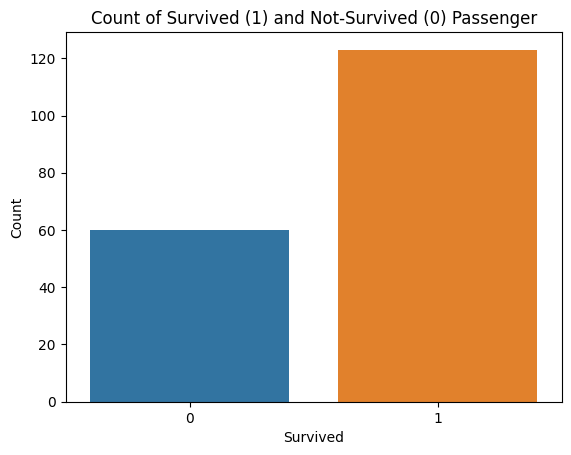

In [ ]:
# Count plot of Survived
sns.countplot(x='Survived', data=titanic_data)
plt.title('Count of Survived (1) and Not-Survived (0) Passenger')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

#to check if the data umbalanced which it is

In [ ]:
data_y = titanic_data['Survived']
data_x = titanic_data.drop(columns=['Survived'])

In [ ]:
type(data_x) #making sure the x is pandas since an error has been throw couple times because it was numpy type

pandas.core.frame.DataFrame

In [ ]:
data_x.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
1,2,1,38.0,1,0,71.2833,0,0
3,4,1,35.0,1,0,53.1000,0,0
6,7,1,54.0,0,0,51.8625,1,1
10,11,3,4.0,1,1,16.7000,0,0
11,12,1,58.0,0,0,26.5500,0,0


In [ ]:
type(data_x)

pandas.core.frame.DataFrame

In [ ]:
'''data_x = np.hstack((np.ones((data_x.shape[0], 1)), data_x))'''

'data_x = np.hstack((np.ones((data_x.shape[0], 1)), data_x))'

In [ ]:
type(data_x)

pandas.core.frame.DataFrame

In [ ]:
type(data_x)

pandas.core.frame.DataFrame

In [ ]:
data_y

1      1
3      1
6      0
10     1
11     1
      ..
871    1
872    0
879    1
887    1
889    1
Name: Survived, Length: 183, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(data_x,data_y,test_size=0.2, shuffle = True)

In [ ]:
from imblearn.over_sampling import SMOTE #to fix the imblanced data

X_train, y_train = SMOTE(random_state=1,n_jobs=-1).fit_resample(X_train,y_train)

/usr/local/lib/python3.10/dist-packages/imblearn/over_sampling/_smote/base.py:336: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


In [ ]:
type(X_train)

pandas.core.frame.DataFrame

In [ ]:
type(X_test)

pandas.core.frame.DataFrame

In [ ]:
from sklearn.preprocessing import StandardScaler #make the data in certain scale to improve the model training
sc = StandardScaler()
X_train[X_train.columns] = sc.fit_transform(X_train)
X_test[X_test.columns] = sc.transform(X_test)

In [ ]:
type(X_train)

pandas.core.frame.DataFrame

In [ ]:
X_train = X_train.to_numpy(dtype = 'float32')
X_test = X_test.to_numpy(dtype = 'float32')
Y_train = y_train.to_numpy(dtype = 'int64')
Y_test = y_test.to_numpy(dtype = 'int64')

#convert the data to numpay so we can use numpay methods and train the model

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

def loss(yhat, y):
  return np.sum(-y*np.log(yhat) - (1-y)*np.log(1-yhat))

In [ ]:
theta = np.random.randn(X_train.shape[1])

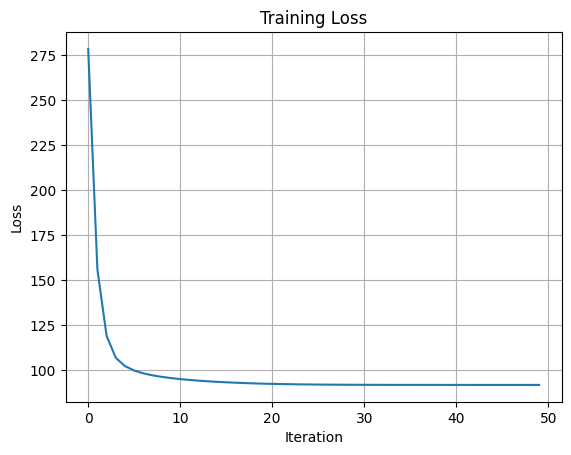

In [ ]:
ls = [] #to gather the losses
lr = 0.01
for i in range(50):
    # Loss
    y_train_pred = sigmoid(X_train @ theta)
    l = loss(y_train_pred, y_train)
    ls.append(l)

    # Gradient step: grad = dL/dtheta
    grad = X_train.T @ (y_train_pred - y_train)
    theta -= lr * grad

plt.figure()
plt.plot(ls)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [ ]:
y_test_pred = sigmoid(X_test @ theta)
prediction = (y_test_pred >= 0.5)
accuracy = np.sum((prediction == y_test)) / len(y_test)
print('Accuracy:', accuracy * 100, '%')

Accuracy: 75.67567567567568 %


In [ ]:
def precision(y_true, y_pred): #how many times the model gussed correctly that the passenger survied to the actual number of survivors

    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    precision = true_positives / (true_positives + false_positives)

    return precision

def accuracy(y_true, y_pred): #how many times the model gussed correctly either the passenger survied or not to the actual data
    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)
    accuracy = correct_predictions / total_predictions

    return accuracy

In [ ]:
# Compute precision for the training dataset
train_precision = precision(y_train, y_train_pred)

# Compute precision for the test dataset
test_precision = precision(y_test, y_test_pred)

# Compute accuracy for the training dataset
train_accuracy = accuracy(y_train, y_train_pred)

# Compute accuracy for the test dataset
test_accuracy = accuracy(y_test, y_test_pred)

# Print the results
print("Training Precision:", train_precision)
print("Training Accuracy:", train_accuracy)
print("Test Precision:", test_precision)
print("Test Accuracy:", test_accuracy)

Training Precision: nan
Training Accuracy: 0.0
Test Precision: nan
Test Accuracy: 0.0


<ipython-input-38-8125ad8a9e10>:5: RuntimeWarning: invalid value encountered in long_scalars
  precision = true_positives / (true_positives + false_positives)
